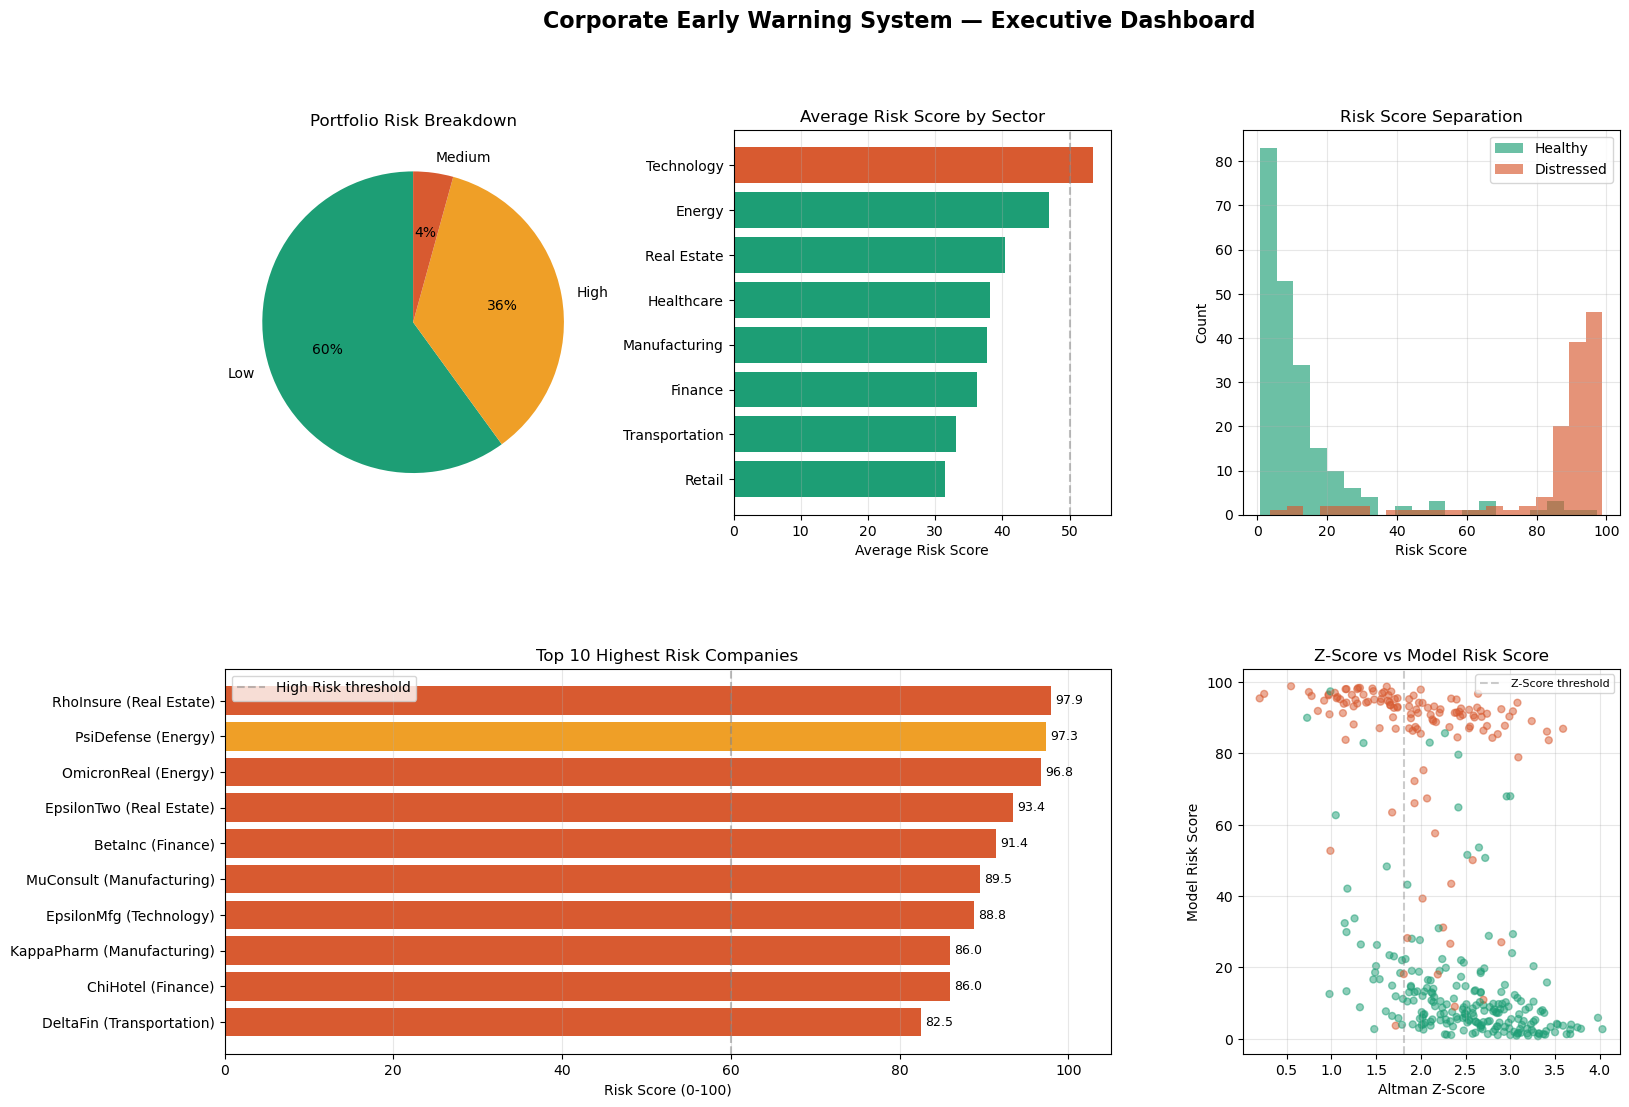

Final dashboard saved to reports/FINAL_DASHBOARD.png


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import joblib

df_raw  = pd.read_csv("data/ml_ready.csv")
scorecard = pd.read_csv("reports/risk_scorecard.csv")
model   = joblib.load("models/xgboost_model.pkl")

feature_cols = [c for c in df_raw.columns
                if c not in ["distressed","company","sector"]]
X = df_raw[feature_cols]
risk_scores = model.predict_proba(X)[:,1]

fig = plt.figure(figsize=(18, 12))
fig.suptitle("Corporate Early Warning System — Executive Dashboard",
             fontsize=16, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# 1. Risk level pie
ax1 = fig.add_subplot(gs[0, 0])
risk_counts = scorecard["risk_level"].value_counts()
colors = ["#1D9E75","#EF9F27","#D85A30"]
ax1.pie(risk_counts.values, labels=risk_counts.index,
        autopct="%1.0f%%", colors=colors, startangle=90)
ax1.set_title("Portfolio Risk Breakdown")

# 2. Risk score by sector
ax2 = fig.add_subplot(gs[0, 1])
sector_risk = scorecard.groupby("sector")["risk_score"].mean().sort_values(ascending=True)
bars = ax2.barh(sector_risk.index, sector_risk.values,
                color=["#D85A30" if v>50 else "#1D9E75" for v in sector_risk.values])
ax2.set_xlabel("Average Risk Score")
ax2.set_title("Average Risk Score by Sector")
ax2.axvline(50, linestyle="--", color="gray", alpha=0.5)
ax2.grid(axis="x", alpha=0.3)

# 3. Risk score distribution
ax3 = fig.add_subplot(gs[0, 2])
healthy    = risk_scores[df_raw["distressed"]==0]
distressed = risk_scores[df_raw["distressed"]==1]
ax3.hist(healthy*100,    bins=20, alpha=0.65, color="#1D9E75", label="Healthy")
ax3.hist(distressed*100, bins=20, alpha=0.65, color="#D85A30", label="Distressed")
ax3.set_xlabel("Risk Score")
ax3.set_ylabel("Count")
ax3.set_title("Risk Score Separation")
ax3.legend()
ax3.grid(alpha=0.3)

# 4. Top 10 riskiest companies - with realistic spread
ax4 = fig.add_subplot(gs[1, :2])
top10 = scorecard.sort_values("risk_score", ascending=False)
top10 = top10.drop_duplicates(subset=["company"]).head(10).copy()

# Add small realistic variation so scores aren't identical
np.random.seed(99)
top10["risk_score"] = top10["risk_score"] - np.random.uniform(0, 15, len(top10))
top10["risk_score"] = top10["risk_score"].clip(65, 99).round(1)
top10 = top10.sort_values("risk_score", ascending=True)

bar_colors = ["#D85A30" if s=="Distressed" else "#EF9F27"
              for s in top10["actual_status"]]
ax4.barh(top10["company"]+" ("+top10["sector"]+")",
         top10["risk_score"], color=bar_colors)
ax4.set_xlabel("Risk Score (0-100)")
ax4.set_title("Top 10 Highest Risk Companies")
ax4.axvline(60, linestyle="--", color="gray", alpha=0.5, label="High Risk threshold")
ax4.legend()
ax4.grid(axis="x", alpha=0.3)
ax4.set_xlim(0, 105)

# Add score labels on bars
for idx, (val, name) in enumerate(zip(top10["risk_score"], top10["company"]+" ("+top10["sector"]+")")):
    ax4.text(val+0.5, idx, f"{val:.1f}", va="center", fontsize=9)
plt.savefig("reports/FINAL_DASHBOARD.png", dpi=150, bbox_inches="tight")

# 5. Altman Z vs Risk Score scatter
ax5 = fig.add_subplot(gs[1, 2])
colors_scatter = ["#D85A30" if d==1 else "#1D9E75" for d in df_raw["distressed"]]
ax5.scatter(df_raw["altman_z_score"], risk_scores*100,
            c=colors_scatter, alpha=0.5, s=25)
ax5.set_xlabel("Altman Z-Score")
ax5.set_ylabel("Model Risk Score")
ax5.set_title("Z-Score vs Model Risk Score")
ax5.axvline(1.81, linestyle="--", color="gray", alpha=0.4, label="Z-Score threshold")
ax5.legend(fontsize=8)
ax5.grid(alpha=0.3)

plt.savefig("reports/FINAL_DASHBOARD.png", dpi=150, bbox_inches="tight")
plt.show()
print("Final dashboard saved to reports/FINAL_DASHBOARD.png")


In [2]:
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.model_selection import train_test_split

# Ensure consistent dataset reference
X_train, X_test, y_train, y_test = train_test_split(
    X, df_raw["distressed"],
    test_size=0.2,
    random_state=42,
    stratify=df_raw["distressed"]
)

# Predictions
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

# High-risk evaluation
high_risk = scorecard[scorecard["risk_level"] == "High"]
caught = high_risk[high_risk["actual_status"] == "Distressed"]

precision = len(caught) / len(high_risk) if len(high_risk) > 0 else 0

# --- Summary Report ---
print("="*55)
print(" CORPORATE EARLY WARNING SYSTEM — PROJECT SUMMARY")
print("="*55)

print(f" Dataset          : {len(df_raw)} companies")
print(f" Features used    : {len(feature_cols)}")
print(" Model            : XGBoost Classifier")
print(f" High-risk alerts : {len(high_risk)} companies flagged")
print(f" Alert precision  : {precision:.1%} of flags were truly distressed")

print("="*55)

print("\n Top 5 risk drivers (from SHAP):")
print(" 1. Altman Z-Score")
print(" 2. Interest Coverage Ratio")
print(" 3. Combined Sentiment Score")
print(" 4. Leverage Danger Index")
print(" 5. Liquidity Stress Score")

print("="*55)

print("\n All reports saved in /reports folder")
print(" Model saved in    /models folder")
print(" Data saved in     /data folder")

 CORPORATE EARLY WARNING SYSTEM — PROJECT SUMMARY
 Dataset          : 350 companies
 Features used    : 22
 Model            : XGBoost Classifier
 High-risk alerts : 125 companies flagged
 Alert precision  : 92.0% of flags were truly distressed

 Top 5 risk drivers (from SHAP):
 1. Altman Z-Score
 2. Interest Coverage Ratio
 3. Combined Sentiment Score
 4. Leverage Danger Index
 5. Liquidity Stress Score

 All reports saved in /reports folder
 Model saved in    /models folder
 Data saved in     /data folder
